# Prétraitement SITG par arrêt et par thème

Ce notebook prépare les données de l'onglet Léman Express avant leur intégration dans l'app. Il produit un fichier GeoJSON par arrêt de transport, avec les géométries de chaque objet proche de l'arrêt et des propriétés normalisées pour filtrer par thème, couche, distance, source et type d'analyse.

Structure de sortie proposée :

- `public/data/stations-theme-preprocessed/stops/{station_id}.geojson` : toutes les géométries autour d'un arrêt, toutes thématiques confondues.
- `public/data/stations-theme-preprocessed/stops/{station_id}.summary.json` : statistiques prêtes à afficher dans la sidebar.
- `public/data/stations-theme-preprocessed/summaries/station_theme_metrics.csv` : table consolidée des métriques.
- `public/data/stations-theme-preprocessed/manifest.json` : index pour l'app ou pour un futur bucket R2.

Le notebook utilise en priorité les couches SITG et ajoute quelques données OpenStreetMap via Overpass pour démontrer le mélange de sources ouvertes. Les requêtes sont volontairement paramétrables pour pouvoir ajuster les couches, les filtres et les statistiques avant de publier les fichiers.

## Dépendances

Installer si nécessaire :

```bash
pip install -r notebooks/requirements-station-preprocessing.txt
```

Le notebook travaille en WGS84 pour les fichiers GeoJSON et projette temporairement en EPSG:2056 pour les distances, surfaces et longueurs.

In [1]:
from __future__ import annotations

import json
import math
import os
import re
from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

Path('/tmp/matplotlib-cache').mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-cache')

import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import requests
from shapely.errors import GEOSException
from shapely.geometry import Point, box, mapping
from shapely.validation import make_valid
from tqdm.auto import tqdm

pd.set_option('display.max_columns', 80)

/Users/marc-ed/BAS-local/repos/swiss-proximity/atlas-swiss-proximity-v2/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SITG_BASE_URL = 'https://vector.sitg.ge.ch/arcgis/rest/services'
OVERPASS_URL = 'https://overpass-api.de/api/interpreter'
HTTP_HEADERS = {'User-Agent': 'atlas-swiss-proximity/0.1 station-preprocessing'}
REPO_ROOT = Path.cwd() if (Path.cwd() / 'public').exists() else Path.cwd().parent
OUTPUT_ROOT = (REPO_ROOT / 'public/data/stations-theme-preprocessed').resolve()
STOPS_DIR = OUTPUT_ROOT / 'stops'
SUMMARY_DIR = OUTPUT_ROOT / 'summaries'

CRS_WGS84 = 'EPSG:4326'
CRS_METRIC = 'EPSG:2056'
ANALYSIS_RADIUS_M = 1000
QUERY_RADIUS_M = 1100

RINGS = [
    {'id': '250', 'from_m': 0, 'to_m': 250, 'label': '0-250m'},
    {'id': '500', 'from_m': 250, 'to_m': 500, 'label': '250-500m'},
    {'id': '750', 'from_m': 500, 'to_m': 750, 'label': '500-750m'},
    {'id': '1000', 'from_m': 750, 'to_m': 1000, 'label': '750-1000m'},
]

TRAM_LINES = ['12', '14', '15', '17', '18']
FOCUS_BOUNDS = (5.9, 46.05, 6.35, 46.32)

# Mode notebook interactif: éviter qu'une couche SITG/Overpass lente bloque longtemps la prévisualisation.
SITG_TIMEOUT_S = 20
OVERPASS_TIMEOUT_S = 25
HTTP_RETRIES = 2
RUN_OSM_IN_PREVIEW = False
PREVIEW_THEME_IDS = ['amenities']

## Catalogue des couches

Les identifiants `theme_id` et `layer_id` sont stables : ils servent dans les exports, les statistiques et l'app. Les couches très lourdes peuvent être gardées dans le catalogue mais désactivées par défaut.

In [3]:
THEMES = {
    'amenities': {
        'label': 'Aménités',
        'objective': "Lire l'offre d'équipements accessibles autour de l'arrêt.",
        'layers': ['PrimarySchool', 'College', 'CarePlace', 'SportFacility', 'MajorRetail', 'PostOffice', 'ParkRide', 'Lighting'],
        'osm_layers': ['OSMDrinkingWater', 'OSMToilets'],
        'include_accidents': False,
    },
    'safety': {
        'label': 'Sécurité vélos/piétons',
        'objective': 'Repérer les secteurs exposés pour les usagers vulnérables.',
        'layers': ['Lighting', 'BikeFacilities', 'PedestrianNetworks', 'TrafficCalming'],
        'osm_layers': ['OSMStreetLighting', 'OSMCrossingsSignals'],
        'include_accidents': True,
    },
    'greenPublic': {
        'label': 'Espaces verts & publics',
        'objective': 'Évaluer la qualité de vie, le paysage et les espaces ouverts.',
        'layers': ['SportFacility', 'PublicSpaces', 'Benches', 'Bins', 'NaturalHabitats'],
        'osm_layers': ['OSMTrees', 'OSMDrinkingWater'],
        'include_accidents': False,
    },
    'activeMobility': {
        'label': 'Mobilité douce',
        'objective': 'Analyser la marchabilité, la cyclabilité et les ruptures.',
        'layers': ['ParkRide', 'Lighting', 'BikeFacilities', 'PedestrianNetworks', 'Cyclevasions', 'HikingTrails', 'TrafficCalming'],
        'osm_layers': ['OSMBicycleParking', 'OSMCycleRepair', 'OSMCrossingsSignals'],
        'include_accidents': True,
    },
    'urbanism': {
        'label': 'Urbanisme & courtes distances',
        'objective': 'Analyser densité bâtie, mixité habitat/emplois et projets urbains.',
        'layers': ['ParkRide', 'Buildings', 'PlanGuideProjects', 'PlanGuideUrbanization', 'LandUseZones', 'PopulationJobs'],
        'osm_layers': [],
        'include_accidents': False,
    },
}

LAYERS = {
    'PrimarySchool': {'theme_hint': 'amenities', 'kind': 'equipment', 'label': 'Écoles primaires', 'service': 'DIP_ECOLES_PRIMAIRE', 'name_field': 'NOM_ETABLISSEMENT', 'detail_fields': ['TYPE_ETABLISSEMENT'], 'address_field': 'ADRESSE'},
    'College': {'theme_hint': 'amenities', 'kind': 'equipment', 'label': 'Collèges', 'service': 'DIP_COLLEGES', 'name_field': 'NOM_ETABLISSEMENT', 'detail_fields': ['TYPE_ETABLISSEMENT'], 'address_field': 'ADRESSE'},
    'CarePlace': {'theme_hint': 'amenities', 'kind': 'equipment', 'label': 'Lieux de soins', 'service': 'DEAS_LIEUX_DE_SOINS', 'name_field': 'NOM_ETABLISSEMENT', 'detail_fields': [], 'address_field': 'ADRESSE'},
    'SportFacility': {'theme_hint': 'amenities', 'kind': 'equipment', 'label': 'Équipements sportifs', 'service': 'UNI_SPORTS_EQUIPEMENTS', 'name_field': 'NOM_EQUIPEMENT', 'detail_fields': ['CATEGORIE_EQUIPEMENT']},
    'MajorRetail': {'theme_hint': 'amenities', 'kind': 'equipment', 'label': 'Commerces majeurs', 'service': 'Hosted/AGGLO_INST_FORTE_FREQ', 'name_field': 'comm_nom', 'detail_fields': ['activite'], 'address_field': 'adresse'},
    'PostOffice': {'theme_hint': 'amenities', 'kind': 'equipment', 'label': 'Offices postaux', 'service': 'GEO_POSTE_PT', 'name_field': 'NOM', 'detail_fields': ['DESCRIPTION1']},
    'ParkRide': {'theme_hint': 'amenities', 'kind': 'equipment', 'label': 'P+R', 'service': 'AGGLO_P_R', 'name_field': 'NOM_DUSUEL', 'detail_fields': ['ETAT', 'CAPACITE_ACTUELLE']},
    'Lighting': {'theme_hint': 'amenities', 'kind': 'equipment', 'label': 'Éclairage public', 'service': 'OTC_SL_RESEAU_MAT', 'name_field': 'TYPE_DE_MAT', 'detail_fields': ['REMARQUE']},
    'PublicSpaces': {'theme_hint': 'greenPublic', 'kind': 'thematic', 'label': 'Espaces publics', 'service': 'OBS_EQUIPEMENTS_ESPACES_PUB', 'where': "LEG_1 IN ('9','91')", 'name_field': 'NOM_USUEL', 'detail_fields': ['TYPE', 'CATEGORIE', 'SOUS_CATEGORIE']},
    'Benches': {'theme_hint': 'greenPublic', 'kind': 'thematic', 'label': 'Bancs publics', 'service': 'VDG_SEV_BANCS', 'name_field': 'MODELE', 'detail_fields': ['MODELE']},
    'Bins': {'theme_hint': 'greenPublic', 'kind': 'thematic', 'label': 'Corbeilles', 'service': 'VDG_CORBEILLES_DECHETS', 'name_field': 'MODELE', 'detail_fields': ['GESTIONNAIRE', 'INSTALLATION']},
    'EcologicalInfrastructure': {'theme_hint': 'greenPublic', 'kind': 'thematic', 'label': 'Infrastructure écologique', 'service': 'AGGLO_IE_PERIMETRE', 'name_field': 'STATUT', 'detail_fields': ['STATUT'], 'enabled_by_default': False, 'max_allowable_offset': '0.00035'},
    'NaturalHabitats': {'theme_hint': 'greenPublic', 'kind': 'thematic', 'label': 'Milieux naturels', 'service': 'SIPV_MN_CARTO_10', 'name_field': 'CAT_MN_10', 'detail_fields': ['CAT_MN_10', 'CODE_10'], 'max_allowable_offset': '0.00008'},
    'BikeFacilities': {'theme_hint': 'activeMobility', 'kind': 'thematic', 'label': 'Aménagements cyclables', 'service': 'OTC_AMENAG_2ROUES', 'name_field': 'NOM_VOIE', 'detail_fields': ['TYPE_AMENAGEMENT', 'REALISATION', 'CIRCUL2R']},
    'PedestrianNetworks': {'theme_hint': 'activeMobility', 'kind': 'thematic', 'label': 'Réseaux piétons', 'service': 'SPD_RESEAUX_PIETONS', 'name_field': 'NATURE', 'detail_fields': ['STATUT', 'COMMUNE']},
    'Cyclevasions': {'theme_hint': 'activeMobility', 'kind': 'thematic', 'label': 'Itinéraires cyclovasions', 'service': 'OTC_CYCLEVASIONS', 'name_field': 'NOM', 'detail_fields': ['TYPE', 'STATUT']},
    'HikingTrails': {'theme_hint': 'activeMobility', 'kind': 'thematic', 'label': 'Randonnée pédestre', 'service': 'FFP_ITINERAIRES_RANDO_PEDESTRE', 'name_field': 'NOM_ITINERAIRE', 'detail_fields': ['TYPE_ITINERAIRE', 'MOBILITE_REDUITE']},
    'TrafficCalming': {'theme_hint': 'activeMobility', 'kind': 'thematic', 'label': 'Zones 20-30 km/h', 'service': 'OTC_ZONE_MODERATION_TRAFIC', 'name_field': 'NOM_ZONE', 'detail_fields': ['TYPE_ZONE', 'LIMITE_VITESSE']},
    'Buildings': {'theme_hint': 'urbanism', 'kind': 'thematic', 'label': 'Bâtiments hors-sol', 'service': 'CAD_BATIMENT_HORSOL', 'name_field': 'NOMBAT', 'detail_fields': ['DESTINATION', 'HAUTEUR', 'NIVEAUX_HORSOL'], 'max_allowable_offset': '0.00003'},
    'PlanGuideProjects': {'theme_hint': 'urbanism', 'kind': 'thematic', 'label': 'Plans guides - projets', 'service': 'SIT_PG_PERIMETRE_PROJET_S_PUB', 'name_field': 'NOM', 'detail_fields': ['NOM']},
    'PlanGuideUrbanization': {'theme_hint': 'urbanism', 'kind': 'thematic', 'label': 'Plans guides - urbanisation', 'service': 'SIT_PG_URBA_PERIMETRE_S_PUB', 'name_field': 'NOM', 'detail_fields': ['NOM']},
    'LandUseZones': {'theme_hint': 'urbanism', 'kind': 'thematic', 'label': "Zones d'affectation", 'service': 'Hosted/AGGLO_ZONE_AFF_SIMPLIFIEE', 'name_field': 'libfvg', 'detail_fields': ['libfvg', 'codeurb', 'commune'], 'max_allowable_offset': '0.00008'},
    'PopulationJobs': {'theme_hint': 'urbanism', 'kind': 'thematic', 'label': 'Population / emplois', 'service': 'AGGLO_CARREAU_200', 'name_field': 'GRID_ID', 'detail_fields': ['DENSITE_POP_HA', 'DENSITE_EMP_HA', 'POP_TOT_GG_2019', 'EMP_TOT_GG_19_20']},
}

ACCIDENT_LAYER = {
    'id': 'Accident',
    'kind': 'accident',
    'label': 'Accidents vélos/piétons',
    'service': 'Hosted/OTC_ACCIDENTS',
    'where': '(nb_bicyclettes > 0 OR nb_vae_25 > 0 OR nb_vae_45 > 0 OR nb_pietons > 0)',
    'out_fields': 'id_accident,consequences,nb_tues,nb_blesses_graves,nb_blesses_legers,nb_bicyclettes,nb_vae_25,nb_vae_45,nb_pietons,conditions_lumineuses,commune,annee,date_,heure,cause,type',
}

OSM_LAYERS = {
    'OSMStreetLighting': {'theme_hint': 'safety', 'kind': 'open_data', 'label': 'Éclairage public OSM', 'overpass': 'node["highway"="street_lamp"]({bbox});', 'name': 'Lampadaire OSM', 'detail_tags': ['lamp_type', 'lit', 'operator']},
    'OSMBicycleParking': {'theme_hint': 'activeMobility', 'kind': 'open_data', 'label': 'Stationnement vélo OSM', 'overpass': 'node["amenity"="bicycle_parking"]({bbox});', 'name': 'Stationnement vélo OSM', 'detail_tags': ['capacity', 'covered', 'bicycle_parking']},
    'OSMCycleRepair': {'theme_hint': 'activeMobility', 'kind': 'open_data', 'label': 'Réparation vélo OSM', 'overpass': 'node["amenity"="bicycle_repair_station"]({bbox});', 'name': 'Station de réparation vélo OSM', 'detail_tags': ['service:bicycle:pump', 'opening_hours']},
    'OSMCrossingsSignals': {'theme_hint': 'activeMobility', 'kind': 'open_data', 'label': 'Traversées et feux OSM', 'overpass': 'node["highway"~"^(crossing|traffic_signals)$"]({bbox});', 'name': 'Traversée / feu OSM', 'detail_tags': ['highway', 'crossing', 'traffic_signals']},
    'OSMDrinkingWater': {'theme_hint': 'greenPublic', 'kind': 'open_data', 'label': 'Eau potable OSM', 'overpass': 'node["amenity"="drinking_water"]({bbox});', 'name': 'Eau potable OSM', 'detail_tags': ['drinking_water', 'seasonal']},
    'OSMToilets': {'theme_hint': 'amenities', 'kind': 'open_data', 'label': 'Toilettes publiques OSM', 'overpass': 'node["amenity"="toilets"]({bbox});', 'name': 'Toilettes publiques OSM', 'detail_tags': ['access', 'fee', 'wheelchair', 'opening_hours']},
    'OSMTrees': {'theme_hint': 'greenPublic', 'kind': 'open_data', 'label': 'Arbres OSM', 'overpass': 'node["natural"="tree"]({bbox});', 'name': 'Arbre OSM', 'detail_tags': ['species', 'genus', 'leaf_type']},
}

## Helpers ArcGIS/SITG et Overpass/OSM

Les services SITG exposent des couches ArcGIS. Les données OSM sont récupérées via Overpass sur la même enveloppe. Les fonctions ci-dessous ajoutent la pagination SITG, détectent les réponses HTML de maintenance et limitent les requêtes autour de l'arrêt.

In [4]:
def slugify(value: str) -> str:
    value = value.lower().strip()
    value = re.sub(r'[^a-z0-9]+', '-', value)
    return re.sub(r'-+', '-', value).strip('-') or 'station'


def station_envelope(lon: float, lat: float, radius_m: int = QUERY_RADIUS_M) -> dict[str, float]:
    lat_delta = radius_m / 110_540
    lon_delta = radius_m / (111_320 * max(0.2, math.cos(math.radians(lat))))
    return {'xmin': lon - lon_delta, 'ymin': lat - lat_delta, 'xmax': lon + lon_delta, 'ymax': lat + lat_delta, 'spatialReference': {'wkid': 4326}}


def ring_for_distance(distance_m: float | None) -> dict[str, Any] | None:
    if distance_m is None or pd.isna(distance_m):
        return None
    for ring in RINGS:
        if ring['from_m'] <= distance_m <= ring['to_m']:
            return ring
    return None


def layer_url(service: str) -> str:
    return f"{SITG_BASE_URL}/{service}/FeatureServer/0/query"


def request_geojson(service: str, params: dict[str, Any], page_size: int = 2000) -> dict[str, Any]:
    all_features: list[dict[str, Any]] = []
    offset = 0
    while True:
        query = {
            'f': 'geojson',
            'where': '1=1',
            'outFields': '*',
            'returnGeometry': 'true',
            'resultRecordCount': page_size,
            'resultOffset': offset,
            **params,
        }
        last_timeout: Exception | None = None
        for attempt in range(1, HTTP_RETRIES + 1):
            try:
                response = requests.get(layer_url(service), params=query, headers=HTTP_HEADERS, timeout=SITG_TIMEOUT_S)
                break
            except requests.exceptions.Timeout as exc:
                last_timeout = exc
                if attempt < HTTP_RETRIES:
                    print(f"{service}: timeout {attempt}/{HTTP_RETRIES}, nouvel essai")
        else:
            raise TimeoutError(f"{service}: timeout SITG après {SITG_TIMEOUT_S}s") from last_timeout
        text = response.text.strip()
        if not response.ok:
            raise RuntimeError(f"{service}: HTTP {response.status_code} {text[:160]}")
        if text.startswith('<'):
            raise RuntimeError(f"{service}: réponse HTML reçue, service probablement indisponible")
        data = response.json()
        if 'error' in data:
            raise RuntimeError(f"{service}: {data['error']}")
        features = data.get('features', [])
        all_features.extend(features)
        if len(features) < page_size and not data.get('exceededTransferLimit'):
            break
        offset += page_size
    return {'type': 'FeatureCollection', 'features': all_features}


def query_layer_near_station(layer: dict[str, Any], station: pd.Series) -> gpd.GeoDataFrame:
    params = {
        'where': layer.get('where', '1=1'),
        'outFields': layer.get('out_fields', '*'),
        'geometry': json.dumps(station_envelope(station.lon, station.lat)),
        'geometryType': 'esriGeometryEnvelope',
        'inSR': 4326,
        'spatialRel': 'esriSpatialRelIntersects',
        'outSR': 4326,
    }
    if layer.get('max_allowable_offset'):
        params['maxAllowableOffset'] = layer['max_allowable_offset']
    collection = request_geojson(layer['service'], params)
    if not collection['features']:
        return empty_geo_dataframe()
    return gpd.GeoDataFrame.from_features(collection, crs=CRS_WGS84)


def station_bbox_for_overpass(station: pd.Series, radius_m: int = QUERY_RADIUS_M) -> str:
    envelope = station_envelope(station.lon, station.lat, radius_m=radius_m)
    return f"{envelope['ymin']},{envelope['xmin']},{envelope['ymax']},{envelope['xmax']}"


def query_osm_layer_near_station(layer: dict[str, Any], station: pd.Series) -> gpd.GeoDataFrame:
    bbox = station_bbox_for_overpass(station)
    query = f"""
    [out:json][timeout:{OVERPASS_TIMEOUT_S}];
    (
      {layer['overpass'].format(bbox=bbox)}
    );
    out tags center;
    """
    response = requests.post(OVERPASS_URL, data={'data': query}, headers=HTTP_HEADERS, timeout=OVERPASS_TIMEOUT_S)
    text = response.text.strip()
    if not response.ok:
        raise RuntimeError(f"Overpass: HTTP {response.status_code} {text[:160]}")
    if text.startswith('<'):
        raise RuntimeError('Overpass: réponse HTML reçue')
    elements = response.json().get('elements', [])
    records = []
    for element in elements:
        lon = element.get('lon') or element.get('center', {}).get('lon')
        lat = element.get('lat') or element.get('center', {}).get('lat')
        if lon is None or lat is None:
            continue
        tags = element.get('tags', {})
        records.append({
            'osm_id': element.get('id'),
            'osm_type': element.get('type'),
            'osm_tags': tags,
            **tags,
            'geometry': Point(float(lon), float(lat)),
        })
    return records_to_gdf(records)

## Chargement des arrêts Léman Express et tram

Les gares Léman Express viennent de `AGGLO_GARES`. Les arrêts de tram viennent de `TPG_ARRETS`, agrégés par nom d'arrêt pour garder une entrée par territoire d'analyse.

In [5]:
def load_leman_express_stations() -> pd.DataFrame:
    data = request_geojson('AGGLO_GARES', {
        'where': "RESEAU='LEX' AND ETAT='en service'",
        'outFields': '*',
        'outSR': 4326,
    })
    gdf = gpd.GeoDataFrame.from_features(data, crs=CRS_WGS84)
    rows = []
    for _, row in gdf.iterrows():
        point = row.geometry
        name = str(row.get('NOMS') or row.get('noms') or 'Gare Léman Express')
        rows.append({
            'station_id': f"sitg-agglo-gares-{row.get('OBJECTID', slugify(name))}",
            'name': name,
            'type': 'Léman Express',
            'source': 'AGGLO_GARES',
            'lines': 'LEX',
            'lon': point.x,
            'lat': point.y,
        })
    return pd.DataFrame(rows)


def load_tram_stations() -> pd.DataFrame:
    where = "ligne IN ('" + "','".join(TRAM_LINES) + "')"
    data = request_geojson('Hosted/TPG_ARRETS', {
        'where': where,
        'outFields': '*',
        'outSR': 4326,
    })
    gdf = gpd.GeoDataFrame.from_features(data, crs=CRS_WGS84)
    if gdf.empty:
        return pd.DataFrame(columns=['station_id', 'name', 'type', 'source', 'lines', 'lon', 'lat'])
    columns = {column.lower(): column for column in gdf.columns}
    name_col = columns.get('nom_arret') or columns.get('arret') or columns.get('nom')
    line_col = columns.get('ligne')
    gdf['station_name'] = gdf[name_col].astype(str)
    gdf['line_value'] = gdf[line_col].astype(str) if line_col else 'Tram'
    grouped = []
    for name, group in gdf.groupby('station_name'):
        centroids = group.geometry.to_crs(CRS_METRIC).centroid.to_crs(CRS_WGS84)
        grouped.append({
            'station_id': f"sitg-tpg-arrets-{slugify(name)}",
            'name': name,
            'type': 'Tram TPG',
            'source': 'TPG_ARRETS',
            'lines': ', '.join(sorted(group['line_value'].dropna().astype(str).unique())),
            'lon': float(centroids.x.mean()),
            'lat': float(centroids.y.mean()),
        })
    return pd.DataFrame(grouped)


stations = pd.concat([load_leman_express_stations(), load_tram_stations()], ignore_index=True)
in_focus = stations['lon'].between(FOCUS_BOUNDS[0], FOCUS_BOUNDS[2]) & stations['lat'].between(FOCUS_BOUNDS[1], FOCUS_BOUNDS[3])
stations = stations.loc[in_focus].sort_values(['type', 'name']).reset_index(drop=True)
stations.head(), len(stations)

(            station_id              name           type       source lines  \
 0   sitg-agglo-gares-3         Annemasse  Léman Express  AGGLO_GARES   LEX   
 1  sitg-agglo-gares-19          Chambésy  Léman Express  AGGLO_GARES   LEX   
 2  sitg-agglo-gares-30       Chêne-Bourg  Léman Express  AGGLO_GARES   LEX   
 3  sitg-agglo-gares-27            Coppet  Léman Express  AGGLO_GARES   LEX   
 4  sitg-agglo-gares-22  Creux-de-Genthod  Léman Express  AGGLO_GARES   LEX   
 
         lon        lat  
 0  6.236380  46.199517  
 1  6.147434  46.242732  
 2  6.197648  46.196583  
 3  6.187715  46.317271  
 4  6.161102  46.263553  ,
 58)

## Normalisation et découpage à 1000 m

Chaque objet reçoit les champs communs suivants : `station_id`, `theme_id`, `layer_id`, `layer_label`, `kind`, `name`, `detail`, `distance_m`, `ring_label`, `source_layer`. Les géométries restent en EPSG:4326 dans les fichiers exportés.

In [6]:
def value_to_text(value: Any) -> str | None:
    if value is None or pd.isna(value):
        return None
    text = str(value).strip()
    return text or None


def empty_geo_dataframe(columns: list[str] | None = None) -> gpd.GeoDataFrame:
    names = list(dict.fromkeys([*(columns or []), 'geometry']))
    return gpd.GeoDataFrame({name: [] for name in names}, geometry='geometry', crs=CRS_WGS84)


def records_to_gdf(records: list[dict[str, Any]]) -> gpd.GeoDataFrame:
    if not records:
        return empty_geo_dataframe()
    return gpd.GeoDataFrame(records, geometry='geometry', crs=CRS_WGS84)


def safe_make_valid(geometry):
    if geometry is None or geometry.is_empty:
        return None
    try:
        if geometry.is_valid:
            return geometry
        repaired = make_valid(geometry)
        if repaired is not None and not repaired.is_empty:
            return repaired
    except (GEOSException, ValueError):
        pass
    try:
        repaired = geometry.buffer(0)
        return repaired if repaired is not None and not repaired.is_empty else None
    except (GEOSException, ValueError):
        return None


def clean_geometry_gdf(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    cleaned = gdf.loc[gdf.geometry.notna()].copy()
    if cleaned.empty:
        return cleaned
    cleaned['geometry'] = cleaned.geometry.apply(safe_make_valid)
    return cleaned.loc[cleaned.geometry.notna() & ~cleaned.geometry.is_empty].copy()


def clipped_measure(geometry, station_buffer, measure: str) -> float | None:
    geometry = safe_make_valid(geometry)
    if geometry is None:
        return None
    try:
        clipped = geometry.intersection(station_buffer)
    except GEOSException:
        try:
            clipped = geometry.buffer(0).intersection(station_buffer)
        except GEOSException:
            return None
    if clipped is None or clipped.is_empty:
        return 0.0
    return float(getattr(clipped, measure))


def normalize_layer_gdf(gdf: gpd.GeoDataFrame, layer_id: str, layer: dict[str, Any], theme_id: str, station: pd.Series) -> gpd.GeoDataFrame:
    if gdf.empty:
        return empty_geo_dataframe()
    gdf = clean_geometry_gdf(gdf)
    if gdf.empty:
        return empty_geo_dataframe()
    station_point = gpd.GeoSeries([Point(station.lon, station.lat)], crs=CRS_WGS84).to_crs(CRS_METRIC).iloc[0]
    station_buffer = station_point.buffer(ANALYSIS_RADIUS_M)
    metric = clean_geometry_gdf(gdf.to_crs(CRS_METRIC))
    gdf = gdf.loc[metric.index].copy()
    inside = metric.geometry.intersects(station_buffer)
    gdf = gdf.loc[inside].copy()
    metric = metric.loc[inside].copy()
    if gdf.empty:
        return empty_geo_dataframe()
    representative = metric.geometry.representative_point()
    distances = representative.distance(station_point)
    records = []
    for index, row in gdf.iterrows():
        distance_m = float(distances.loc[index])
        ring = ring_for_distance(distance_m)
        detail = ' · '.join(filter(None, [value_to_text(row.get(field)) for field in layer.get('detail_fields', [])])) or None
        metric_geometry = metric.loc[index].geometry
        records.append({
            'station_id': station.station_id,
            'station_name': station['name'],
            'station_type': station['type'],
            'theme_id': theme_id,
            'theme_label': THEMES[theme_id]['label'],
            'layer_id': layer_id,
            'layer_label': layer['label'],
            'kind': layer['kind'],
            'name': value_to_text(row.get(layer.get('name_field'))) or layer['label'],
            'detail': detail,
            'address': value_to_text(row.get(layer.get('address_field'))) if layer.get('address_field') else None,
            'source_type': 'SITG',
            'source_layer': layer['service'],
            'distance_m': round(distance_m),
            'ring_label': ring['label'] if ring else 'intersecte 1000m',
            'ring_from_m': ring['from_m'] if ring else None,
            'ring_to_m': ring['to_m'] if ring else None,
            'area_m2': clipped_measure(metric_geometry, station_buffer, 'area') if metric_geometry.geom_type in ['Polygon', 'MultiPolygon'] else None,
            'length_m': clipped_measure(metric_geometry, station_buffer, 'length') if metric_geometry.geom_type in ['LineString', 'MultiLineString'] else None,
            'building_area_m2': row.get('SURFACE') or row.get('Shape__Area') or row.get('SHAPE__Area'),
            'building_height_m': row.get('HAUTEUR'),
            'building_levels': row.get('NIVEAUX_HORSOL'),
            'population': row.get('POP_TOT_GG_2019') or row.get('POP_TOT_GG_2015'),
            'employment': row.get('EMP_TOT_GG_19_20') or row.get('EMP_TOT_GG_15_20'),
            'density_pop_ha': row.get('DENSITE_POP_HA'),
            'density_emp_ha': row.get('DENSITE_EMP_HA'),
            'zone_label': row.get('libfvg') or row.get('LIBFVG') or row.get('codeurb') or row.get('CODEURB'),
            'geometry': row.geometry,
        })
    return records_to_gdf(records)


def normalize_osm_gdf(gdf: gpd.GeoDataFrame, layer_id: str, layer: dict[str, Any], theme_id: str, station: pd.Series) -> gpd.GeoDataFrame:
    if gdf.empty:
        return empty_geo_dataframe()
    station_point = gpd.GeoSeries([Point(station.lon, station.lat)], crs=CRS_WGS84).to_crs(CRS_METRIC).iloc[0]
    metric = gdf.to_crs(CRS_METRIC)
    distances = metric.geometry.distance(station_point)
    gdf = gdf.loc[distances <= ANALYSIS_RADIUS_M].copy()
    distances = distances.loc[gdf.index]
    records = []
    for index, row in gdf.iterrows():
        distance_m = float(distances.loc[index])
        ring = ring_for_distance(distance_m)
        tags = row.get('osm_tags') if isinstance(row.get('osm_tags'), dict) else {}
        detail = ' · '.join(filter(None, [value_to_text(tags.get(tag) or row.get(tag)) for tag in layer.get('detail_tags', [])])) or None
        records.append({
            'station_id': station.station_id,
            'station_name': station['name'],
            'station_type': station['type'],
            'theme_id': theme_id,
            'theme_label': THEMES[theme_id]['label'],
            'layer_id': layer_id,
            'layer_label': layer['label'],
            'kind': layer['kind'],
            'name': value_to_text(tags.get('name')) or layer['name'],
            'detail': detail,
            'source_type': 'OSM',
            'source_layer': 'OpenStreetMap / Overpass',
            'osm_id': row.get('osm_id'),
            'osm_type': row.get('osm_type'),
            'osm_tags': tags,
            'distance_m': round(distance_m),
            'ring_label': ring['label'] if ring else None,
            'ring_from_m': ring['from_m'] if ring else None,
            'ring_to_m': ring['to_m'] if ring else None,
            'geometry': row.geometry,
        })
    return records_to_gdf(records)


def normalize_accidents(gdf: gpd.GeoDataFrame, theme_id: str, station: pd.Series) -> gpd.GeoDataFrame:
    if gdf.empty:
        return empty_geo_dataframe()
    station_point = gpd.GeoSeries([Point(station.lon, station.lat)], crs=CRS_WGS84).to_crs(CRS_METRIC).iloc[0]
    metric = gdf.to_crs(CRS_METRIC)
    distances = metric.geometry.distance(station_point)
    gdf = gdf.loc[distances <= ANALYSIS_RADIUS_M].copy()
    distances = distances.loc[gdf.index]
    records = []
    for index, row in gdf.iterrows():
        distance_m = float(distances.loc[index])
        ring = ring_for_distance(distance_m)
        records.append({
            'station_id': station.station_id,
            'station_name': station['name'],
            'station_type': station['type'],
            'theme_id': theme_id,
            'theme_label': THEMES[theme_id]['label'],
            'layer_id': 'Accident',
            'layer_label': ACCIDENT_LAYER['label'],
            'kind': 'accident',
            'name': 'Accident usager vulnérable',
            'source_type': 'SITG',
            'source_layer': ACCIDENT_LAYER['service'],
            'distance_m': round(distance_m),
            'ring_label': ring['label'] if ring else None,
            'ring_from_m': ring['from_m'] if ring else None,
            'ring_to_m': ring['to_m'] if ring else None,
            'consequences': row.get('consequences'),
            'year': row.get('annee'),
            'date': row.get('date_'),
            'hour': row.get('heure'),
            'commune': row.get('commune'),
            'light_conditions': row.get('conditions_lumineuses'),
            'pedestrians': row.get('nb_pietons') or 0,
            'bicycles': row.get('nb_bicyclettes') or 0,
            'eBikes25': row.get('nb_vae_25') or 0,
            'eBikes45': row.get('nb_vae_45') or 0,
            'injured_light': row.get('nb_blesses_legers') or 0,
            'injured_serious': row.get('nb_blesses_graves') or 0,
            'killed': row.get('nb_tues') or 0,
            'geometry': row.geometry,
        })
    return records_to_gdf(records)

## Traitement d'un arrêt

Cette cellule est le cœur du pipeline : elle télécharge les couches utiles pour chaque thème, normalise les objets, ajoute les points OSM sélectionnés, évite les doublons accident/thème et renvoie un GeoDataFrame prêt à exporter.

In [7]:
def process_station(
    station: pd.Series,
    include_disabled_layers: bool = False,
    include_osm: bool = True,
    theme_ids: list[str] | None = None,
) -> gpd.GeoDataFrame:
    outputs: list[gpd.GeoDataFrame] = []
    layer_cache: dict[str, gpd.GeoDataFrame] = {}
    osm_cache: dict[str, gpd.GeoDataFrame] = {}
    accident_cache: gpd.GeoDataFrame | None = None
    selected_theme_ids = set(theme_ids) if theme_ids else None
    for theme_id, theme in THEMES.items():
        if selected_theme_ids is not None and theme_id not in selected_theme_ids:
            continue
        for layer_id in theme['layers']:
            layer = LAYERS[layer_id]
            if layer.get('enabled_by_default') is False and not include_disabled_layers:
                continue
            if layer_id not in layer_cache:
                try:
                    layer_cache[layer_id] = query_layer_near_station(layer, station)
                except Exception as exc:
                    print(f"{station['name']} · {layer_id}: {exc}")
                    layer_cache[layer_id] = empty_geo_dataframe()
            normalized = normalize_layer_gdf(layer_cache[layer_id], layer_id, layer, theme_id, station)
            if not normalized.empty:
                outputs.append(normalized)
        if include_osm:
            osm_layer_ids = theme.get('osm_layers', [])
        else:
            osm_layer_ids = []
        for layer_id in osm_layer_ids:
            layer = OSM_LAYERS[layer_id]
            if layer_id not in osm_cache:
                try:
                    osm_cache[layer_id] = query_osm_layer_near_station(layer, station)
                except Exception as exc:
                    print(f"{station['name']} · {layer_id}: {exc}")
                    osm_cache[layer_id] = empty_geo_dataframe()
            normalized_osm = normalize_osm_gdf(osm_cache[layer_id], layer_id, layer, theme_id, station)
            if not normalized_osm.empty:
                outputs.append(normalized_osm)
        if theme['include_accidents']:
            if accident_cache is None:
                try:
                    accident_cache = query_layer_near_station(ACCIDENT_LAYER, station)
                except Exception as exc:
                    print(f"{station['name']} · accidents: {exc}")
                    accident_cache = empty_geo_dataframe()
            accidents = normalize_accidents(accident_cache, theme_id, station)
            if not accidents.empty:
                outputs.append(accidents)
    if not outputs:
        return empty_geo_dataframe()
    result = pd.concat(outputs, ignore_index=True)
    return gpd.GeoDataFrame(result, geometry='geometry', crs=CRS_WGS84)

## Statistiques destinées à l'app

Les métriques ci-dessous correspondent aux lectures prévues dans la sidebar : volumes d'équipements, accidents graves, densités de mobilier, longueurs de réseaux de mobilité douce, surfaces d'espaces ouverts, densité bâtie, mixité population/emplois et part SITG/OSM.

In [8]:
def numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors='coerce').fillna(0)


def summarize_station(gdf: gpd.GeoDataFrame, station: pd.Series) -> dict[str, Any]:
    buffer_area_ha = math.pi * ANALYSIS_RADIUS_M**2 / 10_000
    summary: dict[str, Any] = {
        'station': station.to_dict(),
        'radius_m': ANALYSIS_RADIUS_M,
        'generated_at': datetime.now(timezone.utc).isoformat(),
        'themes': {},
    }
    for theme_id, theme in THEMES.items():
        subset = gdf[gdf['theme_id'] == theme_id] if not gdf.empty else gdf
        layers = subset.groupby('layer_id').size().to_dict() if not subset.empty else {}
        rings = subset.groupby('ring_label').size().to_dict() if not subset.empty and 'ring_label' in subset else {}
        sources = subset.groupby('source_type').size().to_dict() if not subset.empty and 'source_type' in subset else {}
        theme_summary = {'label': theme['label'], 'feature_count': int(len(subset)), 'layers': layers, 'rings': rings, 'sources': sources}
        if theme_id == 'amenities':
            theme_summary.update({
                'osm_drinking_water': int((subset['layer_id'] == 'OSMDrinkingWater').sum()) if not subset.empty else 0,
                'osm_toilets': int((subset['layer_id'] == 'OSMToilets').sum()) if not subset.empty else 0,
            })
        if theme_id in ['safety', 'activeMobility']:
            acc = subset[subset['kind'] == 'accident']
            theme_summary.update({
                'accidents_total': int(len(acc)),
                'accidents_severe_or_fatal': int(((numeric(acc.get('killed', pd.Series(dtype=float))) > 0) | (numeric(acc.get('injured_serious', pd.Series(dtype=float))) > 0)).sum()) if not acc.empty else 0,
                'accidents_pedestrians': int((numeric(acc.get('pedestrians', pd.Series(dtype=float))) > 0).sum()) if not acc.empty else 0,
                'accidents_bikes': int(((numeric(acc.get('bicycles', pd.Series(dtype=float))) + numeric(acc.get('eBikes25', pd.Series(dtype=float))) + numeric(acc.get('eBikes45', pd.Series(dtype=float)))) > 0).sum()) if not acc.empty else 0,
                'osm_lamps': int((subset['layer_id'] == 'OSMStreetLighting').sum()) if not subset.empty else 0,
                'osm_crossings_signals': int((subset['layer_id'] == 'OSMCrossingsSignals').sum()) if not subset.empty else 0,
            })
        if theme_id == 'greenPublic':
            theme_summary.update({
                'open_space_area_m2': float(numeric(subset.loc[subset['layer_id'].isin(['PublicSpaces', 'NaturalHabitats']), 'area_m2']).sum()) if not subset.empty else 0,
                'benches': int((subset['layer_id'] == 'Benches').sum()) if not subset.empty else 0,
                'bins': int((subset['layer_id'] == 'Bins').sum()) if not subset.empty else 0,
                'osm_trees': int((subset['layer_id'] == 'OSMTrees').sum()) if not subset.empty else 0,
                'osm_drinking_water': int((subset['layer_id'] == 'OSMDrinkingWater').sum()) if not subset.empty else 0,
                'benches_per_ha': round(int((subset['layer_id'] == 'Benches').sum()) / buffer_area_ha, 2) if not subset.empty else 0,
            })
        if theme_id == 'activeMobility':
            theme_summary['active_network_length_m'] = float(numeric(subset.loc[subset['layer_id'].isin(['BikeFacilities', 'PedestrianNetworks', 'Cyclevasions', 'HikingTrails']), 'length_m']).sum()) if not subset.empty else 0
            theme_summary['osm_bicycle_parking'] = int((subset['layer_id'] == 'OSMBicycleParking').sum()) if not subset.empty else 0
            theme_summary['osm_cycle_repair'] = int((subset['layer_id'] == 'OSMCycleRepair').sum()) if not subset.empty else 0
            theme_summary['osm_crossings_signals'] = int((subset['layer_id'] == 'OSMCrossingsSignals').sum()) if not subset.empty else 0
        if theme_id == 'urbanism':
            buildings = subset[subset['layer_id'] == 'Buildings'] if not subset.empty else subset
            popjobs = subset[subset['layer_id'] == 'PopulationJobs'] if not subset.empty else subset
            population = float(numeric(popjobs.get('population', pd.Series(dtype=float))).sum()) if not popjobs.empty else 0
            employment = float(numeric(popjobs.get('employment', pd.Series(dtype=float))).sum()) if not popjobs.empty else 0
            built_area = float(numeric(buildings.get('area_m2', pd.Series(dtype=float))).sum()) if not buildings.empty else 0
            theme_summary.update({
                'buildings': int(len(buildings)),
                'built_area_m2': built_area,
                'built_density_m2_ha': round(built_area / buffer_area_ha, 1),
                'avg_building_height_m': round(float(numeric(buildings.get('building_height_m', pd.Series(dtype=float))).replace(0, pd.NA).dropna().mean()), 1) if not buildings.empty else None,
                'population': population,
                'employment': employment,
                'jobs_per_resident': round(employment / population, 2) if population else None,
            })
        summary['themes'][theme_id] = theme_summary
    return summary


def summary_to_rows(summary: dict[str, Any]) -> list[dict[str, Any]]:
    station = summary['station']
    rows = []
    for theme_id, values in summary['themes'].items():
        row = {'station_id': station['station_id'], 'station_name': station['name'], 'station_type': station['type'], 'theme_id': theme_id, **values}
        row.pop('layers', None)
        row.pop('rings', None)
        rows.append(row)
    return rows

## Prévisualisation sur un arrêt

La cellule suivante permet de valider les statistiques et la carte avant de lancer l'export complet. Changer `SAMPLE_STATION_NAME` pour tester un autre arrêt.

In [9]:
SAMPLE_STATION_NAME = 'Genève'
sample_candidates = stations[stations['name'].str.contains(SAMPLE_STATION_NAME, case=False, na=False)]
sample_station = sample_candidates.iloc[0] if not sample_candidates.empty else stations.iloc[0]
sample_gdf = process_station(sample_station, include_osm=RUN_OSM_IN_PREVIEW, theme_ids=PREVIEW_THEME_IDS)
sample_summary = summarize_station(sample_gdf, sample_station)
pd.DataFrame(summary_to_rows(sample_summary))

,station_id,station_name,station_type,theme_id,label,feature_count,sources,osm_drinking_water,osm_toilets,accidents_total,accidents_severe_or_fatal,accidents_pedestrians,accidents_bikes,osm_lamps,osm_crossings_signals,open_space_area_m2,benches,bins,osm_trees,benches_per_ha,active_network_length_m,osm_bicycle_parking,osm_cycle_repair,buildings,built_area_m2,built_density_m2_ha,avg_building_height_m,population,employment,jobs_per_resident
0,sitg-agglo-gares-29,Genève-Champel,Léman Express,amenities,Aménités,654,{'SITG': 654},0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,sitg-agglo-gares-29,Genève-Champel,Léman Express,safety,Sécurité vélos/piétons,0,{},NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,sitg-agglo-gares-29,Genève-Champel,Léman Express,greenPublic,Espaces verts & publics,0,{},0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,sitg-agglo-gares-29,Genève-Champel,Léman Express,activeMobility,Mobilité douce,0,{},NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,sitg-agglo-gares-29,Genève-Champel,Léman Express,urbanism,Urbanisme & courtes distances,0,{},NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,0.0,0.0,NaN


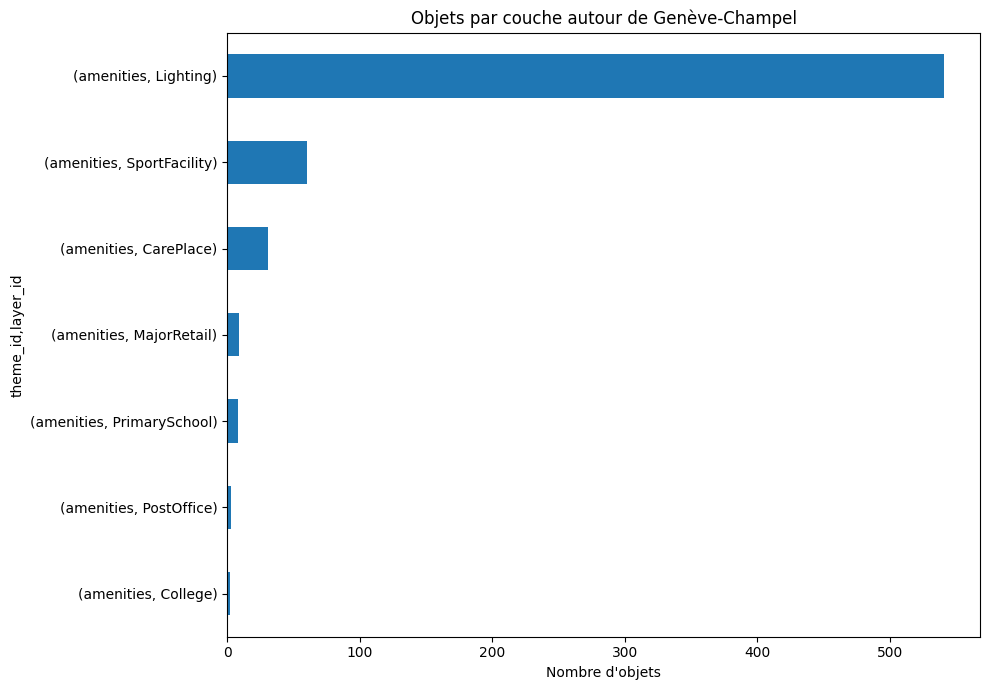

In [10]:
if not sample_gdf.empty:
    ax = sample_gdf.groupby(['theme_id', 'layer_id']).size().sort_values().tail(20).plot(kind='barh', figsize=(10, 7))
    ax.set_title(f"Objets par couche autour de {sample_station['name']}")
    ax.set_xlabel('Nombre d\'objets')
    plt.tight_layout()
else:
    print('Aucune donnée pour cet arrêt')

In [11]:
def preview_map(station: pd.Series, gdf: gpd.GeoDataFrame, theme_id: str | None = None) -> folium.Map:
    m = folium.Map(location=[station.lat, station.lon], zoom_start=15, tiles='CartoDB positron')
    folium.Marker([station.lat, station.lon], tooltip=station['name']).add_to(m)
    for radius, color in [(250, '#32CD32'), (500, '#FFA500'), (750, '#4682B4'), (1000, '#FF69B4')]:
        folium.Circle([station.lat, station.lon], radius=radius, color=color, fill=False, weight=2, tooltip=f'{radius} m').add_to(m)
    subset = gdf[gdf['theme_id'] == theme_id] if theme_id and not gdf.empty else gdf
    if not subset.empty:
        for layer_id, layer_gdf in subset.groupby('layer_id'):
            folium.GeoJson(
                layer_gdf.to_json(),
                name=layer_id,
                tooltip=folium.GeoJsonTooltip(fields=['layer_label', 'name', 'ring_label'], aliases=['Couche', 'Nom', 'Anneau']),
            ).add_to(m)
    folium.LayerControl(collapsed=False).add_to(m)
    return m

preview_map(sample_station, sample_gdf, theme_id=PREVIEW_THEME_IDS[0] if PREVIEW_THEME_IDS else None)

## Export complet

`RUN_FULL_EXPORT` est désactivé par défaut pour éviter de lancer beaucoup de requêtes SITG par accident. Passer à `True` quand la configuration est validée. Le dossier généré peut ensuite être publié tel quel dans un bucket R2 ou servi depuis `public/data`.

In [12]:
def export_station(station: pd.Series, include_disabled_layers: bool = False) -> tuple[dict[str, Any], list[dict[str, Any]]]:
    STOPS_DIR.mkdir(parents=True, exist_ok=True)
    SUMMARY_DIR.mkdir(parents=True, exist_ok=True)
    gdf = process_station(station, include_disabled_layers=include_disabled_layers)
    summary = summarize_station(gdf, station)
    geojson_path = STOPS_DIR / f"{station.station_id}.geojson"
    summary_path = STOPS_DIR / f"{station.station_id}.summary.json"
    if gdf.empty:
        empty = {'type': 'FeatureCollection', 'features': [], 'metadata': summary}
        geojson_path.write_text(json.dumps(empty, ensure_ascii=False, indent=2), encoding='utf-8')
    else:
        payload = json.loads(gdf.to_json(drop_id=True))
        payload['metadata'] = summary
        geojson_path.write_text(json.dumps(payload, ensure_ascii=False), encoding='utf-8')
    summary_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')
    manifest_entry = {
        **station.to_dict(),
        'data_url': f"stops/{station.station_id}.geojson",
        'summary_url': f"stops/{station.station_id}.summary.json",
        'feature_count': int(len(gdf)),
    }
    return manifest_entry, summary_to_rows(summary)


RUN_FULL_EXPORT = False
INCLUDE_DISABLED_LAYERS = True

if RUN_FULL_EXPORT:
    manifest_entries = []
    metric_rows = []
    for _, station in tqdm(stations.iterrows(), total=len(stations)):
        entry, rows = export_station(station, include_disabled_layers=INCLUDE_DISABLED_LAYERS)
        manifest_entries.append(entry)
        metric_rows.extend(rows)
    metrics_df = pd.DataFrame(metric_rows)
    metrics_df.to_csv(SUMMARY_DIR / 'station_theme_metrics.csv', index=False)
    manifest = {
        'format': 'station-theme-preprocessed-v1',
        'generated_at': datetime.now(timezone.utc).isoformat(),
        'crs': CRS_WGS84,
        'analysis_radius_m': ANALYSIS_RADIUS_M,
        'themes': THEMES,
        'layers': LAYERS,
        'osm_layers': OSM_LAYERS,
        'stations': {entry['station_id']: entry for entry in manifest_entries},
        'metrics_url': 'summaries/station_theme_metrics.csv',
    }
    (OUTPUT_ROOT / 'manifest.json').write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding='utf-8')
    print(f"Export terminé: {OUTPUT_ROOT}")
else:
    print('RUN_FULL_EXPORT=False : prévisualisation seulement. Passer à True pour générer les fichiers.')

RUN_FULL_EXPORT=False : prévisualisation seulement. Passer à True pour générer les fichiers.
